In [1]:
import pandas as pd
import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import os
import plotly.graph_objects as go
from sklearn.preprocessing import MinMaxScaler
# Set path
data_path = Path("open-data/data")

# Load competitions
competitions = pd.read_json(data_path / "competitions.json")
competitions.head()

,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
0,9,281,Germany,1. Bundesliga,male,False,False,2023/2024,2024-09-28T20:46:38.893391,2025-07-06T04:26:07.636270,2025-07-06T04:26:07.636270,2024-09-28T20:46:38.893391
1,9,27,Germany,1. Bundesliga,male,False,False,2015/2016,2024-05-19T11:11:14.192381,None,None,2024-05-19T11:11:14.192381
2,1267,107,Africa,African Cup of Nations,male,False,True,2023,2024-09-28T01:57:35.846538,None,None,2024-09-28T01:57:35.846538
3,16,4,Europe,Champions League,male,False,False,2018/2019,2025-05-08T15:10:50.835274,2021-06-13T16:17:31.694,None,2025-05-08T15:10:50.835274
4,16,1,Europe,Champions League,male,False,False,2017/2018,2024-02-13T02:35:28.134882,2021-06-13T16:17:31.694,None,2024-02-13T02:35:28.134882


In [2]:
competitions[['competition_name','season_name']]

,competition_name,season_name
0,1. Bundesliga,2023/2024
1,1. Bundesliga,2015/2016
2,African Cup of Nations,2023
3,Champions League,2018/2019
4,Champions League,2017/2018
...,...,...
70,UEFA Europa League,1988/1989
71,UEFA Women's Euro,2025
72,UEFA Women's Euro,2022
73,Women's World Cup,2023


In [3]:
competitions['season_name'].unique()

array(['2023/2024', '2015/2016', '2023', '2018/2019', '2017/2018',
       '2016/2017', '2014/2015', '2013/2014', '2012/2013', '2011/2012',
       '2010/2011', '2009/2010', '2008/2009', '2006/2007', '2004/2005',
       '2003/2004', '1999/2000', '1972/1973', '1971/1972', '1970/1971',
       '2024', '1983/1984', '1982/1983', '1977/1978', '2020/2021',
       '2019/2020', '1979', '2022', '2018', '1990', '1986', '1974',
       '1970', '1962', '1958', '2021/2022', '2007/2008', '2005/2006',
       '1973/1974', '1997/1998', '1981', '2022/2023', '1977', '1986/1987',
       '2020', '1988/1989', '2025', '2019'], dtype=object)

In [4]:
competitions['competition_name'].unique()

array(['1. Bundesliga', 'African Cup of Nations', 'Champions League',
       'Copa America', 'Copa del Rey', "FA Women's Super League",
       'FIFA U20 World Cup', 'FIFA World Cup', 'Indian Super league',
       'La Liga', 'Liga Profesional', 'Ligue 1', 'Major League Soccer',
       'North American League', 'NWSL', 'Premier League', 'Serie A',
       'UEFA Euro', 'UEFA Europa League', "UEFA Women's Euro",
       "Women's World Cup"], dtype=object)

In [5]:
competitions[competitions['season_name'] == '2025']

,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
71,53,315,Europe,UEFA Women's Euro,female,False,True,2025,2025-07-28T14:19:20.467348,2025-07-29T16:03:07.355174,2025-07-29T16:03:07.355174,2025-07-28T14:19:20.467348


In [6]:
competitions[competitions['season_name'].isin(['2021/2022','2022/2023','2023/2024'])
][['competition_id','season_id','competition_name','season_name']]

,competition_id,season_id,competition_name,season_name
0,9,281,1. Bundesliga,2023/2024
37,1238,108,Indian Super league,2021/2022
58,7,235,Ligue 1,2022/2023
59,7,108,Ligue 1,2021/2022


In [7]:
competition_id = 9     # Bundesliga
season_id = 281        # 2023/2024

matches = pd.read_json(data_path / f"matches/{competition_id}/{season_id}.json")
matches.head()
len(matches)

34

In [8]:
matches.head(4)

,match_id,match_date,kick_off,competition,season,home_team,away_team,home_score,away_score,match_status,match_status_360,last_updated,last_updated_360,metadata,match_week,competition_stage,stadium,referee
0,3895302,2024-04-14,17:30:00.000,"{'competition_id': 9, 'country_name': 'Germany...","{'season_id': 281, 'season_name': '2023/2024'}","{'home_team_id': 904, 'home_team_name': 'Bayer...","{'away_team_id': 176, 'away_team_name': 'Werde...",5,0,available,available,2024-05-10T16:57:53.017895,2024-05-10T17:03:59.613154,"{'data_version': '1.1.0', 'shot_fidelity_versi...",29,"{'id': 1, 'name': 'Regular Season'}","{'id': 377, 'name': 'BayArena', 'country': {'i...","{'id': 234, 'name': 'Harm Osmers', 'country': ..."
1,3895292,2024-04-06,15:30:00.000,"{'competition_id': 9, 'country_name': 'Germany...","{'season_id': 281, 'season_name': '2023/2024'}","{'home_team_id': 190, 'home_team_name': 'Union...","{'away_team_id': 904, 'away_team_name': 'Bayer...",0,1,available,available,2024-05-12T21:04:50.061716,2024-05-12T21:08:37.897296,"{'data_version': '1.1.0', 'shot_fidelity_versi...",28,"{'id': 1, 'name': 'Regular Season'}","{'id': 560, 'name': 'Stadion An der Alten Förs...","{'id': 235, 'name': 'Benjamin Brand', 'country..."
2,3895333,2024-05-05,18:30:00.000,"{'competition_id': 9, 'country_name': 'Germany...","{'season_id': 281, 'season_name': '2023/2024'}","{'home_team_id': 184, 'home_team_name': 'Eintr...","{'away_team_id': 904, 'away_team_name': 'Bayer...",1,5,available,available,2024-05-14T16:23:06.325967,2024-05-14T16:32:13.483516,"{'data_version': '1.1.0', 'shot_fidelity_versi...",32,"{'id': 1, 'name': 'Regular Season'}","{'id': 116458, 'name': 'Deutsche Bank Park', '...","{'id': 237, 'name': 'Christian Dingert', 'coun..."
3,3895340,2024-05-12,20:30:00.000,"{'competition_id': 9, 'country_name': 'Germany...","{'season_id': 281, 'season_name': '2023/2024'}","{'home_team_id': 868, 'home_team_name': 'Bochu...","{'away_team_id': 904, 'away_team_name': 'Bayer...",0,5,available,available,2024-05-14T10:09:25.875345,2024-05-14T16:46:08.459843,"{'data_version': '1.1.0', 'shot_fidelity_versi...",33,"{'id': 1, 'name': 'Regular Season'}","{'id': 550, 'name': 'Vonovia Ruhrstadion', 'co...","{'id': 235, 'name': 'Benjamin Brand', 'country..."


In [9]:
all_events = []

for match_id in matches['match_id']:
    events_file = data_path / f"events/{match_id}.json"
    events = pd.read_json(events_file)
    events['match_id'] = match_id  # add match reference
    all_events.append(events)

events_df = pd.concat(all_events, ignore_index=True)

In [10]:
# Quick check
print(events_df.shape)

(137765, 40)


In [11]:
events_df.head()

,id,index,period,timestamp,minute,second,type,possession,possession_team,play_pattern,...,50_50,foul_won,clearance,ball_recovery,foul_committed,block,substitution,bad_behaviour,match_id,miscontrol
0,794ec549-5288-4d1a-93e8-0fc6d3968784,1,1,2026-03-06 00:00:00.000,0,0,"{'id': 35, 'name': 'Starting XI'}",1,"{'id': 904, 'name': 'Bayer Leverkusen'}","{'id': 1, 'name': 'Regular Play'}",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3895302,NaN
1,3a9a2c57-b177-47ed-9447-11f081b0e388,2,1,2026-03-06 00:00:00.000,0,0,"{'id': 35, 'name': 'Starting XI'}",1,"{'id': 904, 'name': 'Bayer Leverkusen'}","{'id': 1, 'name': 'Regular Play'}",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3895302,NaN
2,1f956a2b-ece0-475b-8802-e82ed922c307,3,1,2026-03-06 00:00:00.000,0,0,"{'id': 18, 'name': 'Half Start'}",1,"{'id': 904, 'name': 'Bayer Leverkusen'}","{'id': 1, 'name': 'Regular Play'}",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3895302,NaN
3,79b90fbb-2cfd-419b-90f4-f0e5980c47d3,4,1,2026-03-06 00:00:00.000,0,0,"{'id': 18, 'name': 'Half Start'}",1,"{'id': 904, 'name': 'Bayer Leverkusen'}","{'id': 1, 'name': 'Regular Play'}",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3895302,NaN
4,221b0c8d-6386-4ae8-bb4a-a1dc98742312,5,1,2026-03-06 00:00:03.417,0,3,"{'id': 30, 'name': 'Pass'}",2,"{'id': 176, 'name': 'Werder Bremen'}","{'id': 9, 'name': 'From Kick Off'}",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3895302,NaN


In [12]:
lineups_list = []

for match_id in matches['match_id']:
    lineup_file = data_path / f"lineups/{match_id}.json"
    lineup = pd.read_json(lineup_file)

    # Add match_id for reference
    lineup['match_id'] = match_id

    lineups_list.append(lineup)

# Combine all lineups
lineups_df = pd.concat(lineups_list, ignore_index=True)

print(lineups_df.shape)


(68, 4)


In [13]:
lineups_df.head()

,team_id,team_name,lineup,match_id
0,904,Bayer Leverkusen,"[{'player_id': 3500, 'player_name': 'Granit Xh...",3895302
1,176,Werder Bremen,"[{'player_id': 5666, 'player_name': 'Dawid Kow...",3895302
2,190,Union Berlin,"[{'player_id': 3117, 'player_name': 'Lucas Tou...",3895292
3,904,Bayer Leverkusen,"[{'player_id': 3500, 'player_name': 'Granit Xh...",3895292
4,904,Bayer Leverkusen,"[{'player_id': 3500, 'player_name': 'Granit Xh...",3895333


In [14]:
comp_path = data_path / f"matches/{competition_id}/{season_id}"
comp_path

WindowsPath('open-data/data/matches/9/281')

In [15]:
def load_matches_from_competition(competition_id,season_id):
    matches_file = data_path / f"matches/{competition_id}/{season_id}.json"

    if not matches_file.exists():
        print(f"No match file found for competition {competition_id}, season {season_id}")
        return pd.DataFrame()  # empty

    matches_df = pd.read_json(matches_file)
    return pd.DataFrame(matches_df)

In [16]:
# Usage
matches_bundesliga = load_matches_from_competition(9,281)
matches_ligue1 = load_matches_from_competition(7,235)
matches_indian = load_matches_from_competition(1238,108)
matches_ligue_21_22 = load_matches_from_competition(7,108)
matches_all = pd.concat([matches_bundesliga, matches_ligue1,matches_indian,matches_ligue_21_22], ignore_index=True)

In [17]:
print(matches_all.shape)
matches_all.head()

(207, 18)


,match_id,match_date,kick_off,competition,season,home_team,away_team,home_score,away_score,match_status,match_status_360,last_updated,last_updated_360,metadata,match_week,competition_stage,stadium,referee
0,3895302,2024-04-14,17:30:00.000,"{'competition_id': 9, 'country_name': 'Germany...","{'season_id': 281, 'season_name': '2023/2024'}","{'home_team_id': 904, 'home_team_name': 'Bayer...","{'away_team_id': 176, 'away_team_name': 'Werde...",5,0,available,available,2024-05-10T16:57:53.017895,2024-05-10T17:03:59.613154,"{'data_version': '1.1.0', 'shot_fidelity_versi...",29,"{'id': 1, 'name': 'Regular Season'}","{'id': 377, 'name': 'BayArena', 'country': {'i...","{'id': 234, 'name': 'Harm Osmers', 'country': ..."
1,3895292,2024-04-06,15:30:00.000,"{'competition_id': 9, 'country_name': 'Germany...","{'season_id': 281, 'season_name': '2023/2024'}","{'home_team_id': 190, 'home_team_name': 'Union...","{'away_team_id': 904, 'away_team_name': 'Bayer...",0,1,available,available,2024-05-12T21:04:50.061716,2024-05-12T21:08:37.897296,"{'data_version': '1.1.0', 'shot_fidelity_versi...",28,"{'id': 1, 'name': 'Regular Season'}","{'id': 560, 'name': 'Stadion An der Alten Förs...","{'id': 235, 'name': 'Benjamin Brand', 'country..."
2,3895333,2024-05-05,18:30:00.000,"{'competition_id': 9, 'country_name': 'Germany...","{'season_id': 281, 'season_name': '2023/2024'}","{'home_team_id': 184, 'home_team_name': 'Eintr...","{'away_team_id': 904, 'away_team_name': 'Bayer...",1,5,available,available,2024-05-14T16:23:06.325967,2024-05-14T16:32:13.483516,"{'data_version': '1.1.0', 'shot_fidelity_versi...",32,"{'id': 1, 'name': 'Regular Season'}","{'id': 116458, 'name': 'Deutsche Bank Park', '...","{'id': 237, 'name': 'Christian Dingert', 'coun..."
3,3895340,2024-05-12,20:30:00.000,"{'competition_id': 9, 'country_name': 'Germany...","{'season_id': 281, 'season_name': '2023/2024'}","{'home_team_id': 868, 'home_team_name': 'Bochu...","{'away_team_id': 904, 'away_team_name': 'Bayer...",0,5,available,available,2024-05-14T10:09:25.875345,2024-05-14T16:46:08.459843,"{'data_version': '1.1.0', 'shot_fidelity_versi...",33,"{'id': 1, 'name': 'Regular Season'}","{'id': 550, 'name': 'Vonovia Ruhrstadion', 'co...","{'id': 235, 'name': 'Benjamin Brand', 'country..."
4,3895348,2024-05-18,16:30:00.000,"{'competition_id': 9, 'country_name': 'Germany...","{'season_id': 281, 'season_name': '2023/2024'}","{'home_team_id': 904, 'home_team_name': 'Bayer...","{'away_team_id': 172, 'away_team_name': 'Augsb...",2,1,available,available,2024-05-20T10:11:27.857660,2024-05-20T10:33:09.140760,"{'data_version': '1.1.0', 'shot_fidelity_versi...",34,"{'id': 1, 'name': 'Regular Season'}","{'id': 377, 'name': 'BayArena', 'country': {'i...","{'id': 837, 'name': 'Matthias Jöllenbeck', 'co..."


# Loading Lineups

In [18]:
def load_lineups(matches_df):
    all_players = []

    for match_id in matches_df['match_id']:
        try:
            lineup_file = data_path / f"lineups/{match_id}.json"
            with open(lineup_file, 'r', encoding='utf-8') as f:
                lineup_json = json.load(f)

                # Each team in lineup_json
                for team in lineup_json:
                    team_id = team['team_id']
                    team_name = team['team_name']

                    for player in team['lineup']:
                        # Flatten player data
                        player_flat = {
                            'match_id': match_id,
                            'team_id': team_id,
                            'team_name': team_name,
                            'player_id': player.get('player_id'),
                            'player_name': player.get('player_name'),
                            'player_nickname': player.get('player_nickname'),
                            'jersey_number': player.get('jersey_number'),
                            'country_id': player['country'].get('id') if player.get('country') else None,
                            'country_name': player['country'].get('name') if player.get('country') else None,
                            'cards': player.get('cards', []),
                            'positions': player.get('positions', []),
                            'minutes_played': player.get('minutes_played', 0)
                        }
                        all_players.append(player_flat)

        except Exception as e:
            print(f"Skipping match {match_id} due to error: {e}")

    df = pd.DataFrame(all_players)

    # --- Flatten positions here ---
    df = df.explode('positions').reset_index(drop=True)
    positions_df = pd.json_normalize(df['positions'])
    df = pd.concat([df.drop(columns=['positions']), positions_df], axis=1)

    return df

In [19]:
lineups_df = load_lineups(matches_all)
lineups_df.head()

,match_id,team_id,team_name,player_id,player_name,player_nickname,jersey_number,country_id,country_name,cards,minutes_played,position_id,position,from,to,from_period,to_period,start_reason,end_reason
0,3895302,904,Bayer Leverkusen,3500,Granit Xhaka,None,34,221,Switzerland,[],0,9.0,Right Defensive Midfield,00:00,68:47,1.0,2.0,Starting XI,Tactical Shift
1,3895302,904,Bayer Leverkusen,3500,Granit Xhaka,None,34,221,Switzerland,[],0,11.0,Left Defensive Midfield,68:47,76:47,2.0,2.0,Tactical Shift,Substitution - Off (Tactical)
2,3895302,904,Bayer Leverkusen,7044,Patrik Schick,None,14,60,Czech Republic,[],0,23.0,Center Forward,61:25,None,2.0,NaN,Substitution - On (Tactical),Final Whistle
3,3895302,904,Bayer Leverkusen,8221,Jonathan Tah,None,4,85,Germany,[],0,4.0,Center Back,00:00,None,1.0,NaN,Starting XI,Final Whistle
4,3895302,904,Bayer Leverkusen,8667,Lukáš Hrádecký,None,1,77,Finland,[],0,1.0,Goalkeeper,00:00,None,1.0,NaN,Starting XI,Final Whistle


# Extracting Central Midfielders

In [20]:
cm_positions = [
    "Central Midfield",
    "Left Center Midfield",
    "Right Center Midfield",
    "Defensive Midfield",
    "Attacking Midfield"
]

cm_players_df = lineups_df[lineups_df['position'].isin(cm_positions)].copy()

print(cm_players_df.shape)

(617, 19)


# Loading Events

In [21]:
def load_events(matches_df):
    all_events = []

    for match_id in matches_df['match_id']:
        event_file = data_path / "events" / f"{match_id}.json"

        if not event_file.exists():
            continue

        with open(event_file) as f:
            events = pd.read_json(event_file)

        events['match_id'] = match_id
        all_events.append(events)

    if all_events:
        return pd.concat(all_events, ignore_index=True)
    else:
        return pd.DataFrame()

In [22]:
events_df = load_events(matches_all)
print(events_df.shape)

(713694, 41)


In [23]:
events_df.head(3)

,id,index,period,timestamp,minute,second,type,possession,possession_team,play_pattern,...,foul_won,clearance,ball_recovery,foul_committed,block,substitution,bad_behaviour,match_id,miscontrol,player_off
0,794ec549-5288-4d1a-93e8-0fc6d3968784,1,1,2026-03-06,0,0,"{'id': 35, 'name': 'Starting XI'}",1,"{'id': 904, 'name': 'Bayer Leverkusen'}","{'id': 1, 'name': 'Regular Play'}",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3895302,NaN,NaN
1,3a9a2c57-b177-47ed-9447-11f081b0e388,2,1,2026-03-06,0,0,"{'id': 35, 'name': 'Starting XI'}",1,"{'id': 904, 'name': 'Bayer Leverkusen'}","{'id': 1, 'name': 'Regular Play'}",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3895302,NaN,NaN
2,1f956a2b-ece0-475b-8802-e82ed922c307,3,1,2026-03-06,0,0,"{'id': 18, 'name': 'Half Start'}",1,"{'id': 904, 'name': 'Bayer Leverkusen'}","{'id': 1, 'name': 'Regular Play'}",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3895302,NaN,NaN


In [24]:
events_df['player_id'] = events_df['player'].apply(
    lambda x: x.get('id') if isinstance(x, dict) else None
)

events_df['event_type'] = events_df['type'].apply(
    lambda x: x.get('name') if isinstance(x, dict) else None
)

## Filtering Only CM Events

In [25]:
cm_player_ids = cm_players_df['player_id'].unique()

cm_events_df = events_df[
    events_df['player_id'].isin(cm_player_ids)
].copy()

print(cm_events_df.shape)

(266767, 43)


## Counting Events Per Player

In [26]:
cm_event_counts = (
    cm_events_df
    .groupby(['player_id', 'event_type'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

cm_event_counts.head()

event_type,player_id,50/50,Bad Behaviour,Ball Receipt*,Ball Recovery,Block,Carry,Clearance,Dispossessed,Dribble,...,Miscontrol,Offside,Own Goal Against,Pass,Player Off,Player On,Pressure,Shield,Shot,Substitution
0,2940.0,0,0,9,1,0,9,0,0,0,...,0,0,0,9,0,0,4,0,0,0
1,2950.0,0,1,129,7,6,114,2,1,2,...,1,0,0,137,0,0,50,0,2,1
2,2995.0,1,1,1076,62,17,934,2,21,53,...,24,0,0,998,1,1,227,0,44,12
3,3108.0,2,0,43,1,3,31,0,1,4,...,1,0,0,41,0,0,39,0,3,0
4,3117.0,1,0,15,6,7,19,4,1,3,...,2,0,0,22,0,0,19,0,0,0


# Merge Minutes Played and Calculate Per-90 Stats

In [27]:
def time_to_minutes(time_str):
    if pd.isna(time_str):
        return None
    minutes, seconds = map(int, time_str.split(':'))
    return minutes + seconds/60

In [28]:
def calculate_minutes_played(lineups_df):

    df = lineups_df.copy()

    df['from_min'] = df['from'].apply(time_to_minutes)
    df['to_min']   = df['to'].apply(time_to_minutes)

    # Then compute minutes played
    df['minutes_played'] = df['to_min'] - df['from_min']

    return df

In [29]:
lineups_df = calculate_minutes_played(lineups_df)

In [30]:
lineups_df[['player_name','from','to','minutes_played']].head()

,player_name,from,to,minutes_played
0,Granit Xhaka,00:00,68:47,68.783333
1,Granit Xhaka,68:47,76:47,8.000000
2,Patrik Schick,61:25,None,NaN
3,Jonathan Tah,00:00,None,NaN
4,Lukáš Hrádecký,00:00,None,NaN


In [31]:
player_stats = events_df.merge(
    lineups_df[['match_id','player_id','player_name','minutes_played']],
    on=['match_id','player_id'],
    how='left'
)

In [32]:
player_stats.head()

,id,index,period,timestamp,minute,second,type,possession,possession_team,play_pattern,...,block,substitution,bad_behaviour,match_id,miscontrol,player_off,player_id,event_type,player_name,minutes_played
0,794ec549-5288-4d1a-93e8-0fc6d3968784,1,1,2026-03-06 00:00:00.000,0,0,"{'id': 35, 'name': 'Starting XI'}",1,"{'id': 904, 'name': 'Bayer Leverkusen'}","{'id': 1, 'name': 'Regular Play'}",...,NaN,NaN,NaN,3895302,NaN,NaN,NaN,Starting XI,NaN,NaN
1,3a9a2c57-b177-47ed-9447-11f081b0e388,2,1,2026-03-06 00:00:00.000,0,0,"{'id': 35, 'name': 'Starting XI'}",1,"{'id': 904, 'name': 'Bayer Leverkusen'}","{'id': 1, 'name': 'Regular Play'}",...,NaN,NaN,NaN,3895302,NaN,NaN,NaN,Starting XI,NaN,NaN
2,1f956a2b-ece0-475b-8802-e82ed922c307,3,1,2026-03-06 00:00:00.000,0,0,"{'id': 18, 'name': 'Half Start'}",1,"{'id': 904, 'name': 'Bayer Leverkusen'}","{'id': 1, 'name': 'Regular Play'}",...,NaN,NaN,NaN,3895302,NaN,NaN,NaN,Half Start,NaN,NaN
3,79b90fbb-2cfd-419b-90f4-f0e5980c47d3,4,1,2026-03-06 00:00:00.000,0,0,"{'id': 18, 'name': 'Half Start'}",1,"{'id': 904, 'name': 'Bayer Leverkusen'}","{'id': 1, 'name': 'Regular Play'}",...,NaN,NaN,NaN,3895302,NaN,NaN,NaN,Half Start,NaN,NaN
4,221b0c8d-6386-4ae8-bb4a-a1dc98742312,5,1,2026-03-06 00:00:03.417,0,3,"{'id': 30, 'name': 'Pass'}",2,"{'id': 176, 'name': 'Werder Bremen'}","{'id': 9, 'name': 'From Kick Off'}",...,NaN,NaN,NaN,3895302,NaN,NaN,34870.0,Pass,Nick Woltemade,68.45


In [33]:
player_stats.columns

Index(['id', 'index', 'period', 'timestamp', 'minute', 'second', 'type',
       'possession', 'possession_team', 'play_pattern', 'team', 'duration',
       'tactics', 'related_events', 'player', 'position', 'location', 'pass',
       'carry', 'under_pressure', 'ball_receipt', 'counterpress', 'out',
       'dribble', 'duel', 'interception', 'off_camera', 'shot', 'goalkeeper',
       'injury_stoppage', '50_50', 'foul_won', 'clearance', 'ball_recovery',
       'foul_committed', 'block', 'substitution', 'bad_behaviour', 'match_id',
       'miscontrol', 'player_off', 'player_id', 'event_type', 'player_name',
       'minutes_played'],
      dtype='object')

In [34]:
player_stats['pass']

0                                                       NaN
1                                                       NaN
2                                                       NaN
3                                                       NaN
4         {'recipient': {'id': 12299, 'name': 'Marvin Du...
                                ...                        
974830                                                  NaN
974831                                                  NaN
974832                                                  NaN
974833                                                  NaN
974834                                                  NaN
Name: pass, Length: 974835, dtype: object

In [35]:
# Example: if pass column is a dict like {'total': 5, 'accurate': 4}
# Count each pass event as 1
player_stats['pass_total'] = player_stats['pass'].apply(lambda x: 1 if isinstance(x, dict) else 0)
player_stats['carry_total'] = player_stats['carry'].apply(lambda x: 1 if isinstance(x, dict) else 0)
player_stats['ball_recovery_total'] = player_stats['ball_recovery'].apply(lambda x: 1 if isinstance(x, dict) else 0)
player_stats['shot_total'] = player_stats['shot'].apply(lambda x: 1 if isinstance(x, dict) else 0)

In [36]:
season_stats = player_stats.groupby(
    ['player_id','player_name']
).sum(numeric_only=True).reset_index()

In [37]:
season_stats.head()

,player_id,player_name,index,period,minute,second,possession,duration,under_pressure,counterpress,out,off_camera,match_id,minutes_played,pass_total,carry_total,ball_recovery_total,shot_total
0,2935.0,Nordi Mukiele Mulere,4487610,3220,100654,60978,182574,1776.031109,304.0,58.0,14.0,27.0,8162929057,34295.100000,649,478,6,8
1,2937.0,Christ-Emmanuel Faitout Maouassa,365259,295,8959,5810,15226,158.672788,42.0,10.0,1.0,3.0,756043058,15410.716667,44,42,0,0
2,2940.0,Jean Eudès Aholou,268664,148,6248,2112,10646,63.018874,14.0,4.0,0.0,2.0,281395582,10.483333,18,18,0,0
3,2946.0,Frédéric Guilbert,885041,637,19083,11627,30075,403.035578,77.0,15.0,3.0,3.0,1599052244,21056.466667,126,91,0,5
4,2947.0,Anthony Lopes,504352,352,11062,6621,22163,307.987779,20.0,0.0,1.0,15.0,887258715,0.000000,83,44,1,0


In [38]:
season_stats.columns

Index(['player_id', 'player_name', 'index', 'period', 'minute', 'second',
       'possession', 'duration', 'under_pressure', 'counterpress', 'out',
       'off_camera', 'match_id', 'minutes_played', 'pass_total', 'carry_total',
       'ball_recovery_total', 'shot_total'],
      dtype='object')

In [39]:
metrics = ['pass_total','carry_total','ball_recovery_total','under_pressure','shot_total']

for metric in metrics:
    season_stats[f'{metric}_per90'] = (
        season_stats[metric] / season_stats['minutes_played']
    ) * 90

In [40]:
season_stats[
    ['player_name','minutes_played',
     'pass_total_per90','carry_total_per90','ball_recovery_total_per90',
     'under_pressure_per90','shot_total_per90']
].head()

,player_name,minutes_played,pass_total_per90,carry_total_per90,ball_recovery_total_per90,under_pressure_per90,shot_total_per90
0,Nordi Mukiele Mulere,34295.100000,1.703159,1.254407,0.015746,0.797782,0.020994
1,Christ-Emmanuel Faitout Maouassa,15410.716667,0.256964,0.245284,0.000000,0.245284,0.000000
2,Jean Eudès Aholou,10.483333,154.531002,154.531002,0.000000,120.190779,0.000000
3,Frédéric Guilbert,21056.466667,0.538552,0.388954,0.000000,0.329115,0.021371
4,Anthony Lopes,0.000000,inf,inf,inf,inf,NaN


In [41]:
season_stats = season_stats[season_stats['minutes_played'] >= 300]

In [42]:
season_stats.replace([np.inf, -np.inf], np.nan, inplace=True)
season_stats.fillna(0, inplace=True)

# Filter Central Midfielders

In [43]:
midfield_positions = [
    'Center Midfield',
    'Left Center Midfield',
    'Right Center Midfield',
    'Center Defensive Midfield',
    'Center Attacking Midfield'
]

midfielders = lineups_df[
    lineups_df['position'].astype(str).str.contains('|'.join(midfield_positions))
]

midfielder_ids = midfielders['player_id'].unique()

midfielder_stats = season_stats[
    season_stats['player_id'].isin(midfielder_ids)
]

In [44]:
midfielder_stats.head()

,player_id,player_name,index,period,minute,second,possession,duration,under_pressure,counterpress,...,minutes_played,pass_total,carry_total,ball_recovery_total,shot_total,pass_total_per90,carry_total_per90,ball_recovery_total_per90,under_pressure_per90,shot_total_per90
5,2950.0,Jonas Martin,1010478,741,22288,13333,42414,414.310578,56.0,10.0,...,10692.500000,137,114,0,2,1.153145,0.959551,0.000000,0.471358,0.016834
13,2995.0,Ángel Fabián Di María Hernández,11227138,8580,259801,165350,501318,5134.858398,868.0,114.0,...,229290.500000,1584,1476,7,67,0.621744,0.579352,0.002748,0.340703,0.026299
15,2999.0,Presnel Kimpembe,11995836,9569,273704,196475,529292,6199.093980,611.0,127.0,...,96724.966667,2194,1694,5,11,2.041458,1.576222,0.004652,0.568519,0.010235
18,3009.0,Kylian Mbappé Lottin,26574703,20130,588912,404826,1095905,10807.339837,3508.0,227.0,...,284899.000000,3132,3429,14,327,0.989403,1.083226,0.004423,1.108182,0.103300
26,3070.0,Florent Mollet,836496,635,17314,12561,34526,365.761301,107.0,11.0,...,17890.733333,110,107,0,4,0.553359,0.538267,0.000000,0.538267,0.020122


# Player Radar Charts

In [45]:
def plot_player_radar_normalized(season_stats, player_id, stats_columns, category_colors=None, save_path=None):
    player_data = season_stats[season_stats['player_id'] == player_id]
    if player_data.empty:
        print(f"No data for player_id {player_id}")
        return

    # Normalize per column
    scaler = MinMaxScaler()
    normalized_df = season_stats.copy()
    normalized_df[stats_columns] = scaler.fit_transform(season_stats[stats_columns])

    # Get the player's normalized values
    player_values = normalized_df.loc[normalized_df['player_id'] == player_id, stats_columns].iloc[0].values

    # Radar setup
    num_vars = len(stats_columns)
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    values = player_values.tolist()
    values += values[:1]
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(6,6), subplot_kw=dict(polar=True))

    # Plot lines per stat with color
    for i in range(num_vars):
        color = category_colors.get(stats_columns[i], 'blue') if category_colors else 'blue'
        ax.plot([angles[i], angles[i+1]], [values[i], values[i+1]], color=color, linewidth=2)

    ax.fill(angles, values, color='blue', alpha=0.25)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(stats_columns, fontsize=10)
    ax.set_title(player_data['player_name'].values[0], fontsize=14, y=1.1)
    ax.set_yticks([0,0.25,0.5,0.75,1])
    ax.set_yticklabels(['0','0.25','0.5','0.75','1'])

    # Save or show
    if save_path:
        os.makedirs(save_path, exist_ok=True)
        plt.savefig(os.path.join(save_path, f"{player_id}_radar_normalized.png"), bbox_inches='tight')
        plt.close()
    else:
        plt.show()

In [46]:
radar_stats = [
    'pass_total_per90', 'carry_total_per90', 'ball_recovery_total_per90',
    'under_pressure_per90', 'shot_total_per90']

# Assign categories colors (attacking vs defensive)
category_colors = {
    'pass_total_per90': 'green',
    'carry_total_per90': 'orange',
    'ball_recovery_total_per90': 'red',
    'under_pressure_per90': 'purple',
    'shot_total_per90': 'blue'}

In [47]:
for pid in midfielder_stats['player_id'].unique():
    plot_player_radar_normalized(midfielder_stats, pid, radar_stats, category_colors, save_path="player_radars_normalized")

In [48]:
def plot_team_radar_interactive(season_stats, team_player_ids, stats_columns, stat_categories):
    """
    Interactive radar chart comparing multiple players with hover info.

    Parameters:
    - season_stats: DataFrame with per-player stats
    - team_player_ids: list of player_ids to include
    - stats_columns: list of stat columns to include in radar
    - stat_categories: dict mapping stat column to category name
    """
    # Filter team players
    team_stats = season_stats[season_stats['player_id'].isin(team_player_ids)]
    if team_stats.empty:
        print("No players found for given IDs.")
        return

    # Normalize stats across all players for fair comparison
    scaler = MinMaxScaler()
    normalized_stats = scaler.fit_transform(season_stats[stats_columns])
    team_norm = normalized_stats[np.isin(season_stats['player_id'], team_player_ids)]

    # Map categories to colors
    category_colors = {'defense':'blue','attack':'red','possession':'green','other':'purple'}
    colors = [category_colors.get(stat_categories.get(stat,'other'),'grey') for stat in stats_columns]

    fig = go.Figure()

    for i, player_id in enumerate(team_player_ids):
        player_values = team_norm[i].tolist()
        player_values += player_values[:1]  # close the loop
        player_name = team_stats[team_stats['player_id']==player_id]['player_name'].values[0]
        fig.add_trace(go.Scatterpolar(
            r=player_values,
            theta=stats_columns + [stats_columns[0]],
            fill='toself',
            name=player_name,
            hoverinfo='text',
            text=[f"{stat}: {val:.2f}" for stat, val in zip(stats_columns, player_values)]
        ))

    fig.update_layout(
        polar=dict(
            radialaxis=dict(visible=True, range=[0,1])
        ),
        showlegend=True,
        title="Interactive Team Radar Chart"
    )

    fig.show()

In [49]:
# Example usage
team_player_ids = [3009, 2950, 3070]

radar_stats = [
    'pass_total_per90', 'carry_total_per90', 'ball_recovery_total_per90',
    'under_pressure_per90', 'shot_total_per90']

stat_categories = {
    'pass_total_per90':'possession',
    'carry_total_per90':'possession',
    'ball_recovery_total_per90':'defense',
    'under_pressure_per90':'defense',
    'shot_total_per90':'attack'}

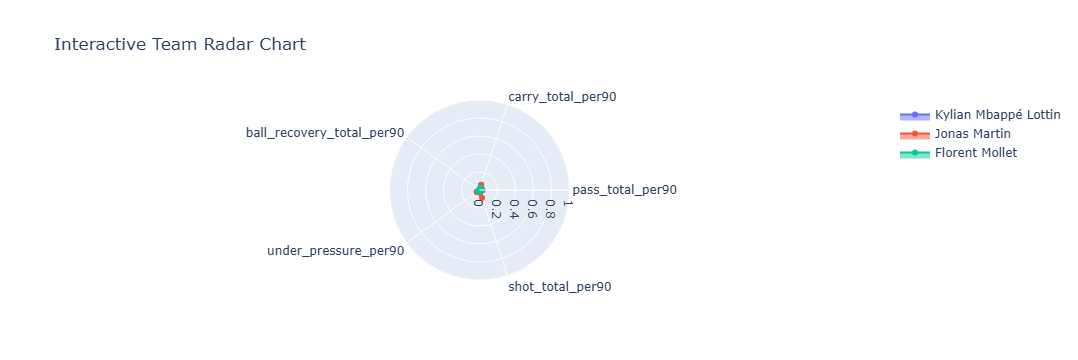

In [50]:
plot_team_radar_interactive(season_stats, team_player_ids, radar_stats, stat_categories)

# Create CM Player Ranking Model

In [51]:
scaler = MinMaxScaler()
midfielder_stats_scaled = midfielder_stats.copy()
midfielder_stats_scaled[metrics] = scaler.fit_transform(midfielder_stats[metrics])

In [52]:
midfielder_stats_scaled['cm_score'] = (
    midfielder_stats_scaled['pass_total_per90'] * 0.30 +
    midfielder_stats_scaled['ball_recovery_total_per90'] * 0.25 +
    midfielder_stats_scaled['carry_total_per90'] * 0.20 +
    midfielder_stats_scaled['under_pressure_per90'] * 0.15 +
    midfielder_stats_scaled['shot_total_per90'] * 0.10
)

In [53]:
cm_ranking = midfielder_stats_scaled.sort_values(
    'cm_score', ascending=False
)

cm_ranking[['player_name','cm_score']].head(10)

,player_name,cm_score
1028,Gaurav Bora,11.824131
1017,Damaitphang Lyngdoh,11.003322
1173,Tim Oermann,7.864610
1168,Gustavo Adolfo Puerta Molano,5.871224
1091,Halicharan Narzary,5.594679
740,Tom Krauß,3.813289
863,Cheikh Ahmadou Bamba Mbacke Dieng,3.733128
596,Jean Lucas de Souza Oliveira,3.555655
121,Anwar El Ghazi,3.516976
903,Balwant Singh,3.315870


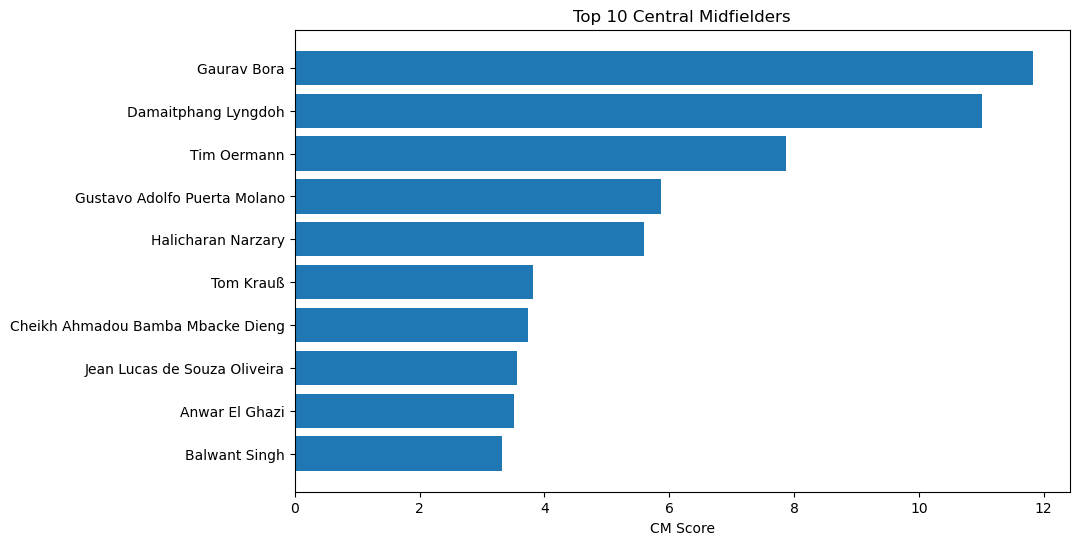

In [54]:
import matplotlib.pyplot as plt

top10 = cm_ranking.head(10)

plt.figure(figsize=(10,6))
plt.barh(top10['player_name'], top10['cm_score'])
plt.gca().invert_yaxis()
plt.title("Top 10 Central Midfielders")
plt.xlabel("CM Score")
plt.show()

# Player Similarity Model

In [55]:
from sklearn.metrics.pairwise import euclidean_distances

def find_similar_players(season_stats, target_player_name, stats_columns, top_n=5):
    """
    Finds top-N most similar players to a target player.

    Parameters:
    - season_stats: DataFrame with per-player stats
    - target_player_name: player name to match
    - stats_columns: list of numeric stats for similarity
    - top_n: number of similar players to return
    """
    # Drop NaN/inf in stats
    stats_clean = season_stats.replace([np.inf, -np.inf], np.nan).dropna(subset=stats_columns)

    # Normalize stats
    scaler = MinMaxScaler()
    stats_clean[stats_columns] = scaler.fit_transform(stats_clean[stats_columns])

    # Find target player
    target_row = stats_clean[stats_clean['player_name'] == target_player_name]
    if target_row.empty:
        print(f"No data for player: {target_player_name}")
        return []

    target_vector = target_row[stats_columns].values

    # Compute Euclidean distance
    other_vectors = stats_clean[stats_columns].values
    distances = euclidean_distances(target_vector, other_vectors).flatten()

    # Get top-N closest (exclude self)
    stats_clean['distance'] = distances
    similar_players = stats_clean[stats_clean['player_name'] != target_player_name].sort_values('distance').head(top_n)

    return similar_players[['player_name'] + stats_columns + ['distance']]

In [56]:
similar = find_similar_players(midfielder_stats, "Granit Xhaka", radar_stats, top_n=5)
similar

,player_name,pass_total_per90,carry_total_per90,ball_recovery_total_per90,under_pressure_per90,shot_total_per90,distance
148,Achraf Hakimi Mouh,0.044634,0.057767,0.005703,0.019337,0.010378,0.005913
5,Jonas Martin,0.042295,0.053966,0.000000,0.013540,0.015367,0.006664
251,Johan Gastien,0.044931,0.051065,0.004377,0.013017,0.015931,0.007630
456,Danilo Luís Hélio Pereira,0.040025,0.051104,0.002065,0.012567,0.011811,0.008297
768,Nuno Mendes,0.035678,0.048521,0.007666,0.019204,0.008928,0.011389


# Player Clustering

In [57]:
# Select the stats for clustering
clustering_stats = [
    'pass_total_per90', 'carry_total_per90', 'ball_recovery_total_per90',
    'under_pressure_per90', 'shot_total_per90']

# Filter out any players with NaN or infinite values
clustering_data = season_stats[clustering_stats].replace([np.inf, -np.inf], np.nan).dropna()

# Optionally, keep player names and IDs for later
player_ids = season_stats.loc[clustering_data.index, 'player_id']
player_names = season_stats.loc[clustering_data.index, 'player_name']

In [58]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(clustering_data)

In [59]:
from sklearn.cluster import KMeans

n_clusters = 6  # choose a number that makes sense for your dataset
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels to your season_stats
season_stats.loc[clustering_data.index, 'cluster'] = clusters

C:\Users\ramku\anaconda3\envs\football\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


In [60]:
for i in range(n_clusters):
    print(f"\nCluster {i}:")
    display(season_stats[season_stats['cluster'] == i][['player_name'] + clustering_stats].head(10))


Cluster 0:


,player_name,pass_total_per90,carry_total_per90,ball_recovery_total_per90,under_pressure_per90,shot_total_per90
0,Nordi Mukiele Mulere,1.703159,1.254407,0.015746,0.797782,0.020994
12,Benjamin André,1.649336,1.220695,0.000000,0.894555,0.000000
15,Presnel Kimpembe,2.041458,1.576222,0.004652,0.568519,0.010235
18,Kylian Mbappé Lottin,0.989403,1.083226,0.004423,1.108182,0.103300
25,Leroy Sané,1.088319,1.114863,0.006636,1.207769,0.026544
34,Andrei Girotto,1.404123,1.060375,0.000000,0.914719,0.011652
41,Julian Draxler,1.972837,1.912267,0.034611,1.315224,0.043264
53,Alassane Pléa,1.731704,1.656413,0.000000,1.091727,0.037646
88,Angelo Fulgini,1.169811,0.943396,0.037736,0.905660,0.000000
92,Renato Júnior Luz Sanches,1.524580,1.446471,0.002893,1.008190,0.028929



Cluster 1:


,player_name,pass_total_per90,carry_total_per90,ball_recovery_total_per90,under_pressure_per90,shot_total_per90
121,Anwar El Ghazi,5.765535,5.188981,0.000000,4.612428,0.576553
139,Massadio Haïdara,8.865846,6.066105,0.000000,4.199611,0.933247
154,Yussuf Yurary Poulsen,2.978550,3.419816,0.000000,5.295199,0.661900
195,Gianluigi Donnarumma,16.410790,7.794765,0.000000,4.898743,0.000000
740,Tom Krauß,6.904284,5.948306,0.000000,3.186593,0.743538
786,Mathys Tel,8.411797,9.159513,0.000000,12.711160,1.121573
794,Alidu Seidu,18.529412,16.378676,0.000000,10.919118,0.000000
863,Cheikh Ahmadou Bamba Mbacke Dieng,5.629321,3.851641,0.296280,7.407001,0.888840
913,Ishan Pandita,1.970812,1.780854,0.047489,3.395495,0.783576
993,Arindam Bhattacharja,30.918367,7.448980,0.000000,3.877551,0.000000



Cluster 2:


...

,player_name,pass_total_per90,carry_total_per90,ball_recovery_total_per90,under_pressure_per90,shot_total_per90
1017,Damaitphang Lyngdoh,12.757475,14.352159,0.797342,27.109635,0.398671



Cluster 4:


,player_name,pass_total_per90,carry_total_per90,ball_recovery_total_per90,under_pressure_per90,shot_total_per90
1,Christ-Emmanuel Faitout Maouassa,0.256964,0.245284,0.000000,0.245284,0.000000
3,Frédéric Guilbert,0.538552,0.388954,0.000000,0.329115,0.021371
5,Jonas Martin,1.153145,0.959551,0.000000,0.471358,0.016834
7,Christophe Hérelle,0.420299,0.280199,0.000000,0.200142,0.000000
8,Saîf-Eddine Khaoui,0.405520,0.263588,0.000000,0.405520,0.020276
11,Alexander Djiku,1.149957,0.999963,0.000000,0.499981,0.000000
13,Ángel Fabián Di María Hernández,0.621744,0.579352,0.002748,0.340703,0.026299
14,Ibrahima Niane,0.162081,0.162081,0.000000,0.336630,0.024936
16,Nanitamo Jonathan Ikoné,0.260668,0.285894,0.000000,0.311120,0.016817
20,Nicolas Pépé,0.855884,0.831661,0.000000,0.645950,0.048446



Cluster 5:


,player_name,pass_total_per90,carry_total_per90,ball_recovery_total_per90,under_pressure_per90,shot_total_per90
111,Romain Hamouma,3.114390,2.703056,0.117524,2.262340,0.000000
236,Harold Moukoudi,8.816027,5.510017,0.000000,1.469338,0.000000
246,Gaëtan Perrin,3.246351,3.449248,0.000000,3.652145,0.202897
340,Maximilian Wittek,2.710465,2.258721,0.000000,4.065698,0.000000
418,Jean-Clair Todibo,3.631091,3.222593,0.000000,1.611297,0.045389
428,Farid El Melali,2.077922,2.770563,0.000000,1.558442,0.346320
455,Airam López Cabrera,2.718675,2.296457,0.061788,1.843344,0.298642
496,Riad Nouri,8.489041,3.395616,0.000000,4.123248,0.000000
525,Woo-Yeong Jeong,4.508588,3.113073,0.000000,3.005725,0.000000
589,Kevin Sessa,4.237393,3.568331,0.000000,5.649858,0.000000


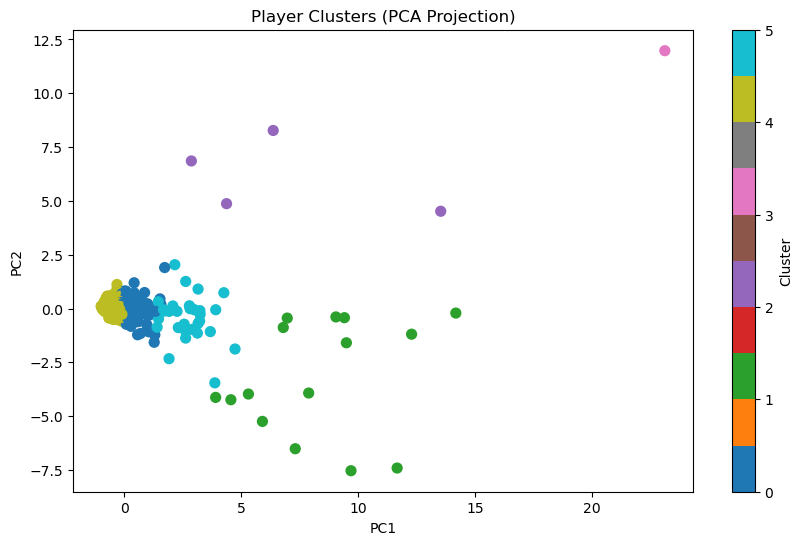

In [61]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap='tab10', s=50)
plt.title("Player Clusters (PCA Projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label='Cluster')
plt.show()

# Saving files

In [62]:
# Ensure the folder exists
os.makedirs("processed_data", exist_ok=True)

# Save lineups
lineups_df.to_csv("processed_data/lineups_clean.csv", index=False)

# Save season stats including per-90 stats and clusters
season_stats.to_csv("processed_data/season_stats_clean.csv", index=False)

print("✅ CSV files saved in 'processed_data/' folder.")

✅ CSV files saved in 'processed_data/' folder.


In [64]:
player_clusters = season_stats[['player_id','player_name','cluster']]
player_clusters.to_csv("processed_data/player_clusters.csv", index=False)